# Тестирование логгирования

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
if 'notebooks' in os.listdir():
    pass
else:
    os.chdir('..')

print(os.getcwd())

C:\Users\kobel\учёба\diploma\fas_aug_attack


## Создание логгера

In [35]:
from src.utils.logging import LoggerOptuna

In [36]:
logger = LoggerOptuna(
    folder_name='test_logging_2',
    experiment_name='test_experiment',
    direction='minimize',
)

In [37]:
def create_img(p1: float, p2: float, p3: float) -> np.ndarray:
    img = np.ones((1200, 900, 3))

    img[:, :, 0] *= p1
    img[:, :, 1] *= p2
    img[:, :, 2] *= p3
    return img

In [38]:
logger.start()

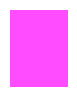

In [39]:
img = create_img(1., 0.3, 1.)

logger.step(
    img=img,
    score=0.983,
    step=1,
    params={'x': 31},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

In [40]:
img = create_img(0.3, 1., 1.)

logger.step(
    img=img,
    score=0.999,
    step=2,
    params={'x': 100},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

MlflowException: Changing param values is not allowed. Param with key='x' was already logged with value='31' for run ID='c5a1d7a82324468196288daf52008d53'. Attempted logging new value '100'.

In [ ]:
img = create_img(1., 1., 0.3)

logger.step(
    img=img,
    score=0.7,
    step=3,
    params={'x': 13},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

In [ ]:
logger.end()

## Создание OptunaPipeline

In [49]:
from src.pipeline import OptunaAttackPipeline

In [ ]:
optuna_attack_pipeline = OptunaAttackPipeline()